### Data preparation

In [20]:
import pandas as pd


df = pd.read_pickle(r'D:\AV\Education\Master\ML\Project\prepared_data\data.pkl')
df.head()

,name,description,neighborhood_overview,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,...,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_verifications_email,host_verifications_phone,host_verifications_work_email,host_age_on_platform
0,Nice flat close to Montparnasse,This beautiful apartment is very well located ...,"The neighborhood is very nice, feel free to sh...","Paris, France","I am living in Paris since 10 years, and I lov...",72,0.0,0.00,False,Invalides - Ecole Militaire,...,False,1,1,0,0,0.57,True,True,False,11.446575
1,"Marais - Charming loft, river view","In the heart of historical Paris le Marais, gr...",Le Marais is the heart of Paris. Few years ago...,"Paris, France","I travel a lot for work and when I'm away, my ...",3,1.0,0.92,True,Saint-Paul - Ile Saint-Louis,...,False,1,1,0,0,0.66,True,True,False,11.446575
2,Superbe 2 pièces idéalement placé,A stone's throw from Parc Monceau and the Arc ...,Quiet and residential area... Close to the Bat...,"Paris, France",NaN,72,0.0,0.00,False,Monceau,...,False,1,1,0,0,NaN,True,True,False,11.471233
3,"Cozy place, Sacré Coeur Montmartre in the SoPi",Cozy apartment close to everything.<br />Perfe...,One of the most trendy corners of the capital ...,"Paris, France","Jeune ingénieur, je propose mon appartement à ...",1,1.0,0.89,False,Pigalle - Saint-Georges,...,False,1,1,0,0,0.72,True,True,False,12.172603
4,Appartement d'architecte - Montmartre,"Our apartment, refurbished by an architect in ...",The apartment is in the heart of Paris's 18th ...,"Paris, France",NaN,1,1.0,1.00,False,Vaugirard,...,False,1,1,0,0,0.25,True,True,False,11.443836


In [ ]:
df2 = df.copy()

df2['host_response_time'] = df2['host_response_time'].apply(int)

for col in ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
    df2[col] = df2[col].apply(bool)

drop_col_list = df2.select_dtypes(exclude=['int', 'bool', 'float']).columns

df2 = df2.drop(columns=list(drop_col_list) + ['latitude', 'longitude'])

# Для признаков, содержащих мало пропусков, просто выкидываю значения
few_null_values_col_list = [
    'host_listings_count',
    'host_total_listings_count',                         
    'minimum_minimum_nights',     
    'maximum_minimum_nights',       
    'minimum_maximum_nights',
    'maximum_maximum_nights',
]
for col in few_null_values_col_list:
    df2 = df2[~df2[col].isna()]

# Признаки, содержащие много пропусков пока просто удаляю
many_null_values_col_list = [
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'reviews_per_month',
    'bedrooms',
]

df2 = df2.drop(columns=many_null_values_col_list)

print('Кол-во пропусков = ', df2.isnull().sum().sum())
print(df2.shape)
"C:\Users\alrvt\Downloads\data (1).pkl"

Кол-во пропусков =  0
(81820, 31)


### KNN

In [88]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [84]:
X = df2.drop(columns=['availability_30'])
y = df2['availability_30']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [94]:
from tqdm import tqdm

100%|██████████| 38/38 [00:27<00:00,  1.40it/s]


<Axes: xlabel='n'>

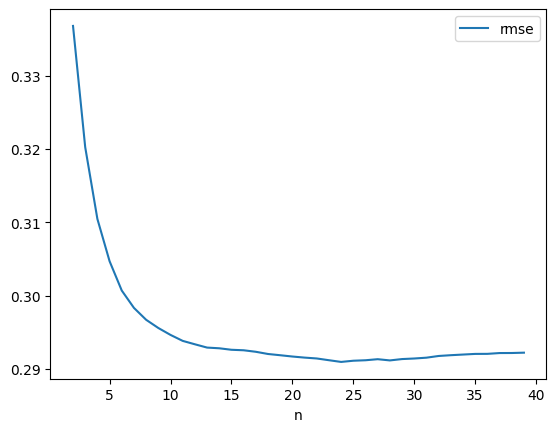

In [100]:


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

res = {
    'n': [],
    'rmse': [],
}

for n in tqdm(range(2, 40)):
    knn = KNeighborsRegressor(
        n_neighbors=n
    )

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    res['n'] += [n]
    res['rmse'] += [root_mean_squared_error(
        y_true=y_test,
        y_pred=y_pred,
    )]

pd.DataFrame(res).plot(kind='line', x='n', y='rmse')

100%|██████████| 38/38 [01:44<00:00,  2.75s/it]


<Axes: xlabel='n'>

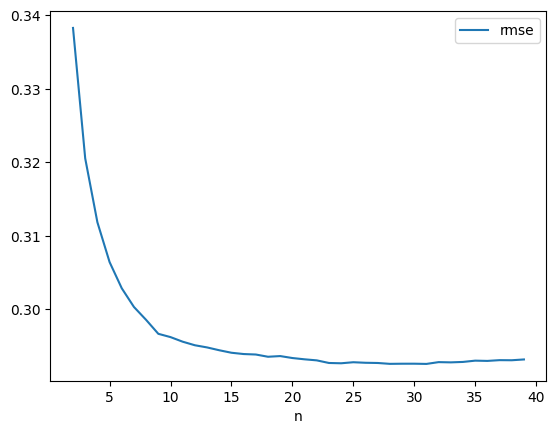

In [105]:
# Импортируем метод PCA из модуля decomposition библиотеки sklearn
from sklearn.decomposition import PCA

# Создадим объект класса PCA с числом главных компонент равным 7
pca = PCA(n_components = 10)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pca.fit_transform(X_train_scaled)
X_test_scaled = pca.transform(X_test_scaled)

res = {
    'n': [],
    'rmse': [],
}

for n in tqdm(range(2, 40)):
    knn = KNeighborsRegressor(
        n_neighbors=n
    )

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    res['n'] += [n]
    res['rmse'] += [root_mean_squared_error(
        y_true=y_test,
        y_pred=y_pred,
    )]

pd.DataFrame(res).plot(kind='line', x='n', y='rmse')

In [103]:
X_train_scaled.shape

(65456, 7)

In [77]:
X_train.isna().sum().sum()

np.int64(14424)

In [ ]:
# # Обратабываем локацию хоста. Если не известно проставлем False, полагая, что это так же не приклекает
# df2['host_paris_location'] = df2['host_location'].apply(lambda x: 'Paris' in x if not pd.isna(x) else False)


# property_type
# room_type

# bathrooms_text

# amenities

# first_review
# last_review

# license

,name,description,neighborhood_overview,host_location,host_about,host_neighbourhood,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,room_type,bathrooms_text,amenities,first_review,last_review,license,instant_bookable
0,Nice flat close to Montparnasse,This beautiful apartment is very well located ...,"The neighborhood is very nice, feel free to sh...","Paris, France","I am living in Paris since 10 years, and I lov...",Invalides - Ecole Militaire,"[email, phone]",True,True,Palais-Bourbon,Entire rental unit,Entire home/apt,1 bath,"[""Wifi"", ""Hot water"", ""Heating"", ""Coffee maker...",2014-05-17,2020-03-13,7510702406383,False
1,"Marais - Charming loft, river view","In the heart of historical Paris le Marais, gr...",Le Marais is the heart of Paris. Few years ago...,"Paris, France","I travel a lot for work and when I'm away, my ...",Saint-Paul - Ile Saint-Louis,"[email, phone]",True,True,Hôtel-de-Ville,Entire rental unit,Entire home/apt,1 bath,"[""Paid parking on premises"", ""Wifi"", ""Free was...",2014-10-29,2025-08-29,7510400455677,False
2,Superbe 2 pièces idéalement placé,A stone's throw from Parc Monceau and the Arc ...,Quiet and residential area... Close to the Bat...,"Paris, France",NaN,Monceau,"[email, phone]",True,False,Batignolles-Monceau,Entire rental unit,Entire home/apt,1 bath,"[""Hair dryer"", ""Iron"", ""TV"", ""Heating"", ""Wifi""...",NaN,NaN,NaN,False
3,"Cozy place, Sacré Coeur Montmartre in the SoPi",Cozy apartment close to everything.<br />Perfe...,One of the most trendy corners of the capital ...,"Paris, France","Jeune ingénieur, je propose mon appartement à ...",Pigalle - Saint-Georges,"[email, phone]",True,True,Opéra,Entire rental unit,Entire home/apt,1 bath,"[""Elevator"", ""Hot water kettle"", ""Wifi"", ""Laun...",2014-05-25,2025-07-03,7510901014972,False
4,Appartement d'architecte - Montmartre,"Our apartment, refurbished by an architect in ...",The apartment is in the heart of Paris's 18th ...,"Paris, France",NaN,Vaugirard,"[email, phone]",True,True,Buttes-Montmartre,Entire rental unit,Entire home/apt,1 bath,"[""Elevator"", ""Wifi"", ""Self check-in"", ""Hot wat...",2023-05-21,2025-07-20,7511808333770,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81848,Apt a/c 1BR/2P - Saint-Lazare/Les Champs Elysée,📌 Checkmyguest offers you a charming and spaci...,🏘️ The 8th arrondissement of Paris is one of t...,"Paris, France",Checkmyguest est une entreprise de gestion loc...,NaN,"[email, phone]",True,True,Élysée,Entire rental unit,Entire home/apt,1 bath,"[""Elevator"", ""Hot water kettle"", ""Wifi"", ""Dini...",2025-08-22,2025-09-14,7510815621419,True
81849,Superbe duplex avec terrasse face Tour Eiffel,The Konciergerie is proud to present this char...,NaN,"Paris, France","Bienvenue à Paris ! \nJe suis Eliav, passionné...",NaN,"[email, phone]",True,True,Vaugirard,Entire rental unit,Entire home/apt,1.5 baths,"[""Hot water kettle"", ""Wifi"", ""Babysitter recom...",NaN,NaN,"Available with a mobility lease only (""bail mo...",True
81850,Cozy studio - 2P - Place des Vosges/Marais,Checkmyguest offers you an exceptional 24 m² s...,"Romantic, festive and trendy, the Marais distr...",NaN,NaN,NaN,"[email, phone]",True,True,Hôtel-de-Ville,Entire rental unit,Entire home/apt,1 bath,"[""Hot water kettle"", ""Wifi"", ""Paid street park...",2025-09-07,2025-09-07,7510406440280,True
81851,Appt entier 35m2 proche Montmartre,Quiet 35 m2 apartment in the heart of Paris.<b...,NaN,"Paris, France","Mon appartement parisien est très cosy, décoré...",Pigalle - Saint-Georges,"[email, phone]",True,True,Opéra,Private room in rental unit,Private room,1 private bath,"[""Wifi"", ""Laundromat nearby"", ""Freezer"", ""Self...",NaN,NaN,NaN,False


In [45]:
for c in df2.dtypes:
    print(c)

str
str
str
str
str
int64
float64
float64
bool
str
float64
float64
object
object
object
str
float64
float64
str
str
int64
str
float64
str
int64
int64
float64
float64
float64
float64
float64
float64
float64
int64
int64
int64
int64
str
str
float64
float64
float64
float64
float64
float64
float64
str
object
int64
int64
int64
int64
float64
bool
bool
bool
float64
bool
